In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from downstream import run_downstream_task, downstream_tasks
from src.downstream_task.plots import plot_results

results_folder = run_downstream_task("weather")
plot_results(results_folder, downstream_tasks)

In [ ]:
from downstream import run_downstream_task, downstream_tasks
from src.downstream_task.plots import plot_results

results_folder = run_downstream_task("auto_sales")
plot_results(results_folder, downstream_tasks)

In [ ]:
from downstream import run_downstream_task, downstream_tasks
from src.downstream_task.plots import plot_results

results_folder = run_downstream_task("movies")
plot_results(results_folder, downstream_tasks)

In [ ]:
from pathlib import Path
from downstream import downstream_tasks
from src.downstream_task.plots import plot_results

results_path = Path("regression-results")
for folder in sorted(results_path.glob("*"), reverse=True):
    plot_results(folder, downstream_tasks)

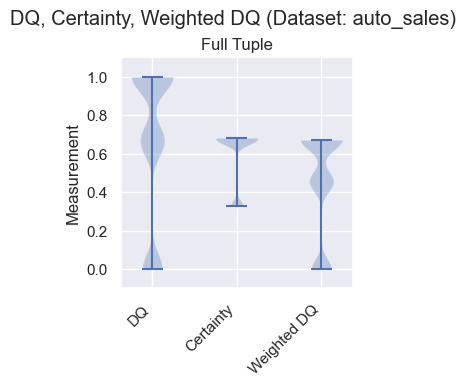

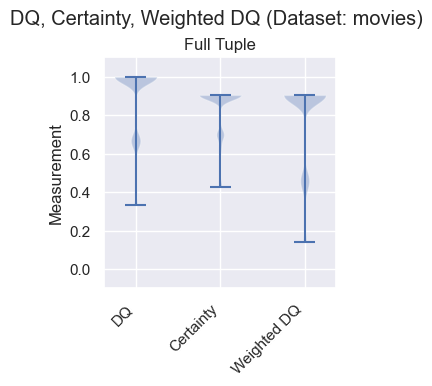

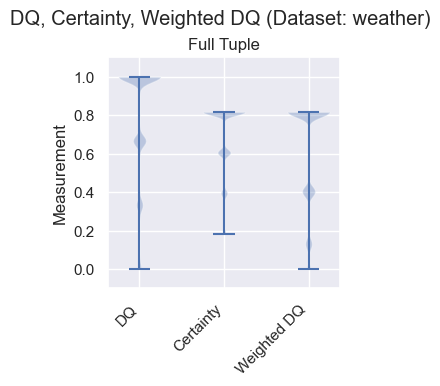

In [ ]:
import numpy as np

from src.utils import get_raw_results, make_labels, grouped_figure, res_raw

import seaborn as sns

sns.set_theme()

df_raw = get_raw_results()
accessors = [
    lambda x: x.dq_result,
    lambda x: x.certainty,
    lambda x: np.array(x.dq_result) * np.array(x.certainty),
]
for (dataset, metric, dimension), (column,), col_group, ax, fig, pos in grouped_figure(
    df_raw[
        (df_raw["metric"] != "completeness_nullRatio")
        & (df_raw["type"] == "polluted")
        & (df_raw["pollution_mechanism"] == "ECAR")
        & (df_raw["pollution_rate"] == 0.35)
        & (df_raw["dimension"] == "consistency_tuple")
    ],
    ["dataset", "metric", "dimension"],
    ["column"],
):
    row, col, nrows, ncols = pos
    assert len(col_group) == 1
    polluted_col_data = col_group.iloc[0]
    labels = ["DQ", "Certainty", "Weighted DQ"]
    x = np.arange(1, len(labels) + 1)

    measurements = [get_field(res_raw(col_group)[0]) for get_field in accessors]

    parts = ax.violinplot(measurements)

    ax.set_title(column)
    ax.set_ylim(-0.1, 1.1)
    ax.tick_params(axis="x", which="both")
    for pc in parts["bodies"]:  # cmaxes cbars
        pc.set_facecolor(f"C{row}")
    if col == 0:
        ax.set_ylabel("Measurement")
    ax.set_xticks(x, labels=labels, rotation=45, ha="right")
    fig.suptitle(
        f"DQ, Certainty, Weighted DQ (Dataset: {dataset})",
        y=1.04,
    )